# 04 - Student Wellbeing Analysis

Analyze marginalization, discrimination, and substance use concerns.

In [1]:
import sys
sys.path.insert(0, '../scripts')
from helpers import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load and clean data
df = load_survey_data()
df = clean_survey_data(df)
print(f"Loaded {len(df)} survey responses")

Loaded 50 survey responses


In [3]:
# Find marginalization column
margin_col = [col for col in df.columns if 'marginalized' in col.lower()][0]
substance_col = [col for col in df.columns if 'tobacco' in col.lower() or 'substance' in col.lower()][0]

print(f"Marginalization column: {margin_col}")
print(f"Substance use column: {substance_col}")

Marginalization column: do_you_feel_marginalized_or_discriminated_against_at_school/college/university?
Substance use column: have_you_ever_used_tobacco,_alcohol,_or_other_substances?


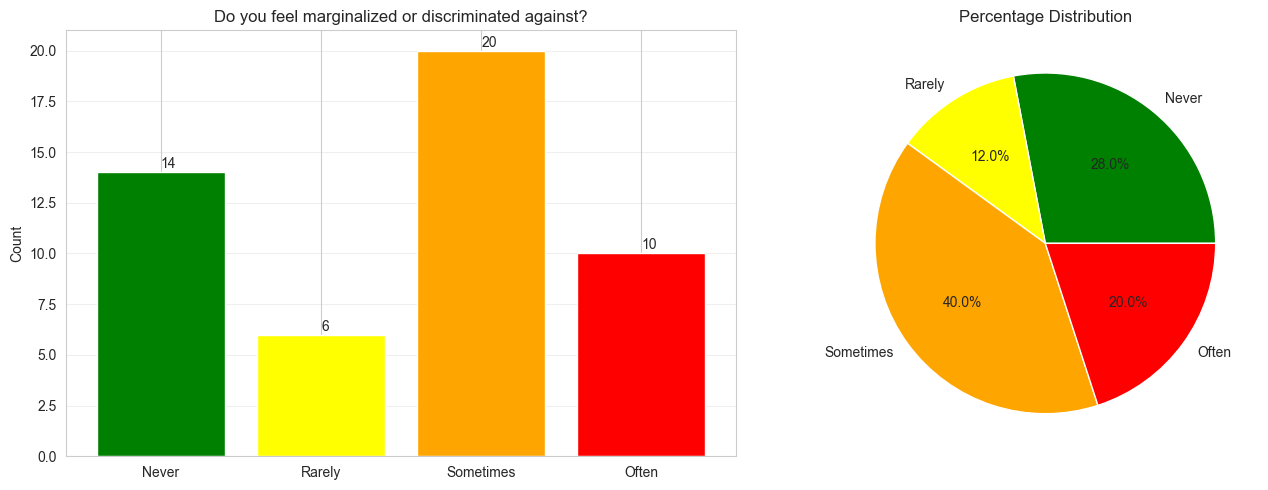


Marginalization Summary:
do_you_feel_marginalized_or_discriminated_against_at_school/college/university?
Sometimes    20
Never        14
Often        10
Rarely        6
Name: count, dtype: int64


In [4]:
# Marginalization distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
margin_counts = df[margin_col].value_counts()
order = ['Never', 'Rarely', 'Sometimes', 'Often']
margin_ordered = [margin_counts.get(m, 0) for m in order]

axes[0].bar(order, margin_ordered, color=['green', 'yellow', 'orange', 'red'])
axes[0].set_ylabel('Count')
axes[0].set_title('Do you feel marginalized or discriminated against?')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(margin_ordered):
    axes[0].text(i, v + 0.2, str(v))

# Pie chart
axes[1].pie(margin_ordered, labels=order, autopct='%1.1f%%', colors=['green', 'yellow', 'orange', 'red'])
axes[1].set_title('Percentage Distribution')

plt.tight_layout()
plt.show()

print(f"\nMarginalization Summary:")
print(margin_counts)

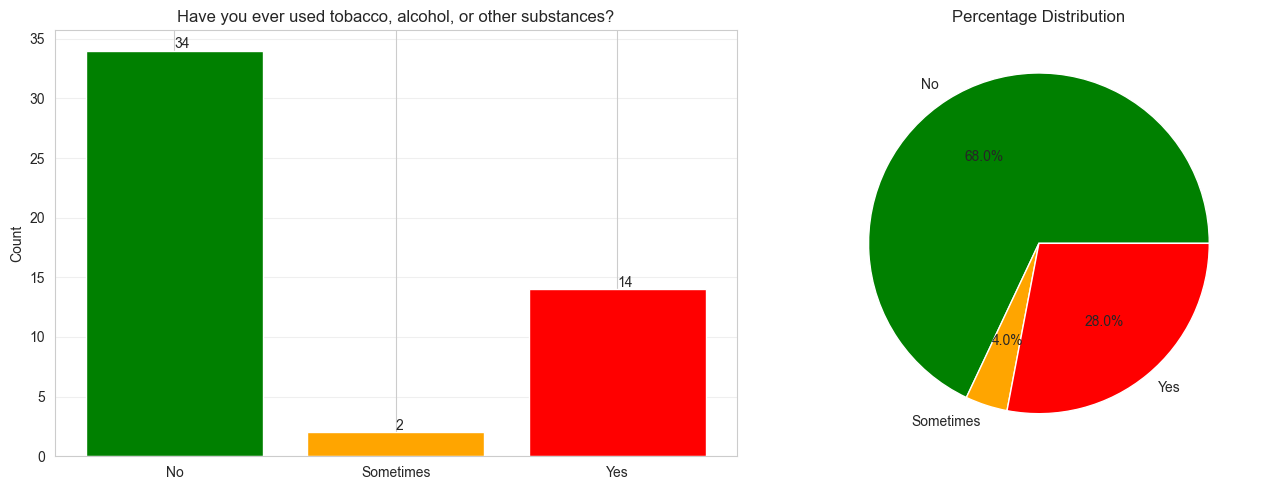


Substance Use Summary:
have_you_ever_used_tobacco,_alcohol,_or_other_substances?
No           34
Yes          14
Sometimes     2
Name: count, dtype: int64


In [5]:
# Substance use distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

substance_counts = df[substance_col].value_counts()
order = ['No', 'Sometimes', 'Yes']
substance_ordered = [substance_counts.get(s, 0) for s in order]

# Bar chart
colors = ['green', 'orange', 'red']
axes[0].bar(range(len(order)), substance_ordered, color=colors[:len(order)])
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(order)
axes[0].set_ylabel('Count')
axes[0].set_title('Have you ever used tobacco, alcohol, or other substances?')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(substance_ordered):
    axes[0].text(i, v + 0.2, str(v))

# Pie chart
axes[1].pie(substance_ordered, labels=order, autopct='%1.1f%%', colors=colors[:len(order)])
axes[1].set_title('Percentage Distribution')

plt.tight_layout()
plt.show()

print(f"\nSubstance Use Summary:")
print(substance_counts)


Marginalization by Gender (%)
do_you_feel_marginalized_or_discriminated_against_at_school/college/university?  Never  \
gender                                                                                   
Female                                                                            15.8   
Male                                                                              36.7   
Prefer Not Say                                                                     0.0   

do_you_feel_marginalized_or_discriminated_against_at_school/college/university?  Often  \
gender                                                                                   
Female                                                                            26.3   
Male                                                                              13.3   
Prefer Not Say                                                                   100.0   

do_you_feel_marginalized_or_discriminated_against_at_school/college

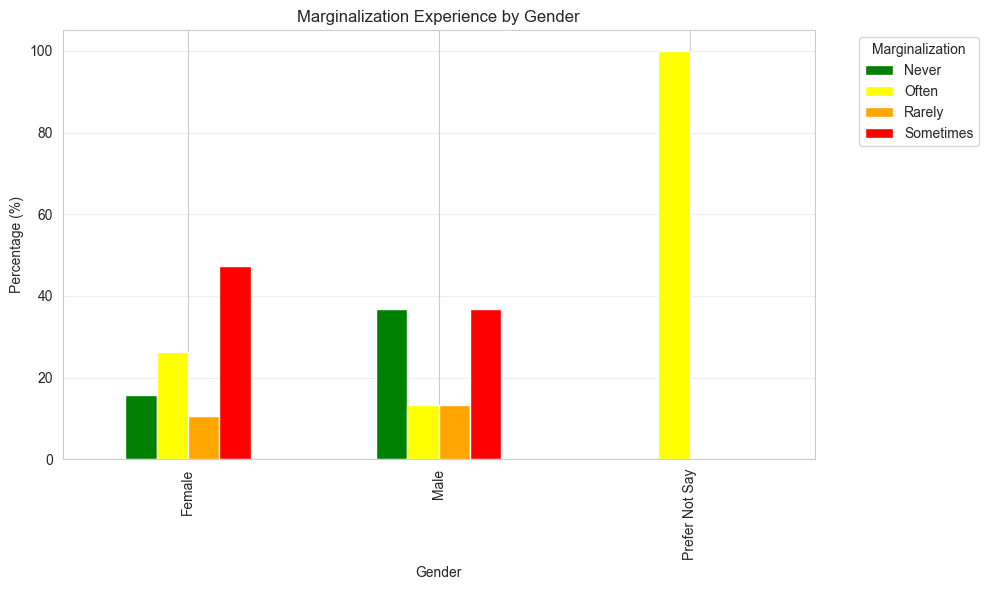

In [6]:
# Cross-analysis: Gender vs Marginalization
cross_analysis = pd.crosstab(df['gender'], df[margin_col], normalize='index') * 100
print("\nMarginalization by Gender (%)")
print(cross_analysis.round(1))

fig, ax = plt.subplots(figsize=(10, 6))
cross_analysis.plot(kind='bar', ax=ax, color=['green', 'yellow', 'orange', 'red'])
ax.set_title('Marginalization Experience by Gender')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Gender')
ax.legend(title='Marginalization', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Substance Use by Study Hours
have_you_ever_used_tobacco,_alcohol,_or_other_substances?  No  Sometimes  Yes
average_hours_spent_studying_per_day                                         
1–2 hours                                                   9          0    4
2–4 hours                                                   9          1    3
Less than 1 hour                                           12          0    6
More than 4 hours                                           4          1    1


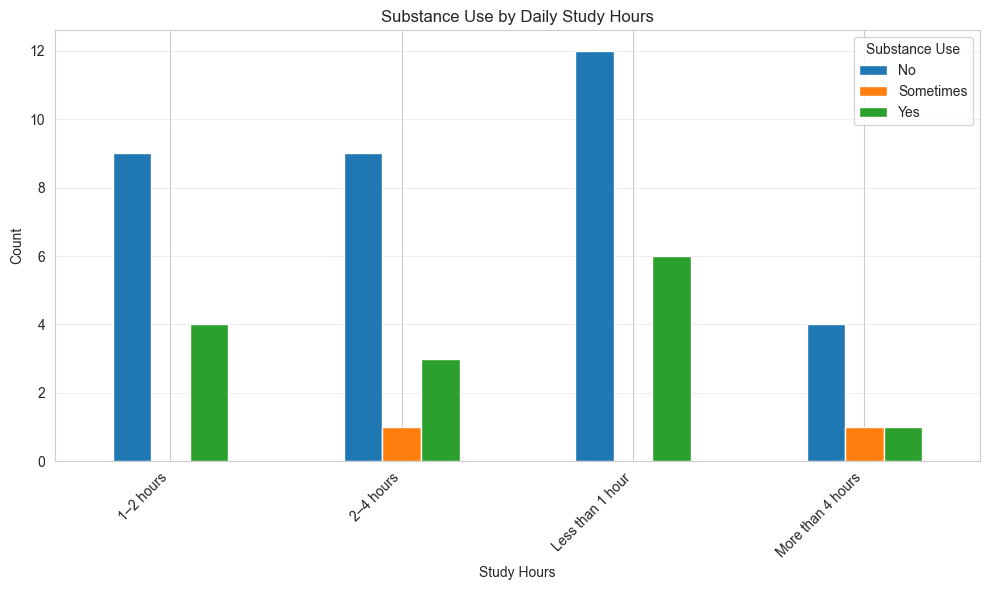

In [7]:
# Cross-analysis: Study Hours vs Substance Use
cross_study = pd.crosstab(df['average_hours_spent_studying_per_day'], df[substance_col])
print("\nSubstance Use by Study Hours")
print(cross_study)

fig, ax = plt.subplots(figsize=(10, 6))
cross_study.plot(kind='bar', ax=ax)
ax.set_title('Substance Use by Daily Study Hours')
ax.set_ylabel('Count')
ax.set_xlabel('Study Hours')
ax.legend(title='Substance Use')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()